# Fetch data from Toronto Open Data API

In [25]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import io

# Get package metadata to find the resource ID
base_url = "https://ckan0.cf.opendata.inter.prod-toronto.ca"
package = requests.get(
    base_url + "/api/3/action/package_show",
    params={"id": "building-permits-active-permits"}
).json()

# Download the datastore-active resource as a CSV (all records in one call)
for resource in package["result"]["resources"]:
    if resource["datastore_active"]:
        csv_data = requests.get(base_url + "/datastore/dump/" + resource["id"]).text
        df = pd.read_csv(io.StringIO(csv_data))
        break

print(f"Loaded {len(df):,} permits")
print(df.head(3))

Loaded 236,394 permits
   _id     PERMIT_NUM  REVISION_NUM                 PERMIT_TYPE  \
0    1  24 246834 PLB             0                Plumbing(PS)   
1    2  07 277219 BLD             0  Small Residential Projects   
2    3  24 158408 TPS             0        Temporary Structures   

      STRUCTURE_TYPE                         WORK STREET_NUM  STREET_NAME  \
0  2 Unit - Detached  Building Permit Related(PS)        336     RUSHOLME   
1            Triplex                       Canopy        452      OAKWOOD   
2      Institutional              Certified Tents          1  BRIDGEPOINT   

  STREET_TYPE STREET_DIRECTION  ...                           EST_CONST_COST  \
0          RD                   ...  DO NOT UPDATE OR DELETE THIS INFO FIELD   
1         AVE                   ...                                   500.00   
2          DR                   ...                                      NaN   

   ASSEMBLY INSTITUTIONAL RESIDENTIAL BUSINESS_AND_PERSONAL_SERVICES  \
0     

/var/folders/91/tzhvh9qd33v4c58ym1d5c0x80000gn/T/ipykernel_2636/385183126.py:17: DtypeWarning: Columns (31) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(io.StringIO(csv_data))


# Clean and Prepare Data

In [26]:
# Parse APPLICATION_DATE and drop rows where it's missing
df["APPLICATION_DATE"] = pd.to_datetime(df["APPLICATION_DATE"], errors="coerce")
df = df.dropna(subset=["APPLICATION_DATE"])

# Keep only 2014 onward
df = df[df["APPLICATION_DATE"].dt.year >= 2014].copy()

# Create a year-month column
df["MONTH"] = df["APPLICATION_DATE"].dt.to_period("M")

# Filter to Small Residential Projects only
top_type = "Small Residential Projects"
df_top = df[df["PERMIT_TYPE"] == top_type]

# Count permits per month
monthly = df_top.groupby("MONTH").size()
monthly.index = monthly.index.to_timestamp()

print("Permit type:", top_type)
print(monthly.tail(3))


Permit type: Small Residential Projects
MONTH
2025-12-01    511
2026-01-01    597
2026-02-01    412
Freq: MS, dtype: int64


# Plot Line Chart

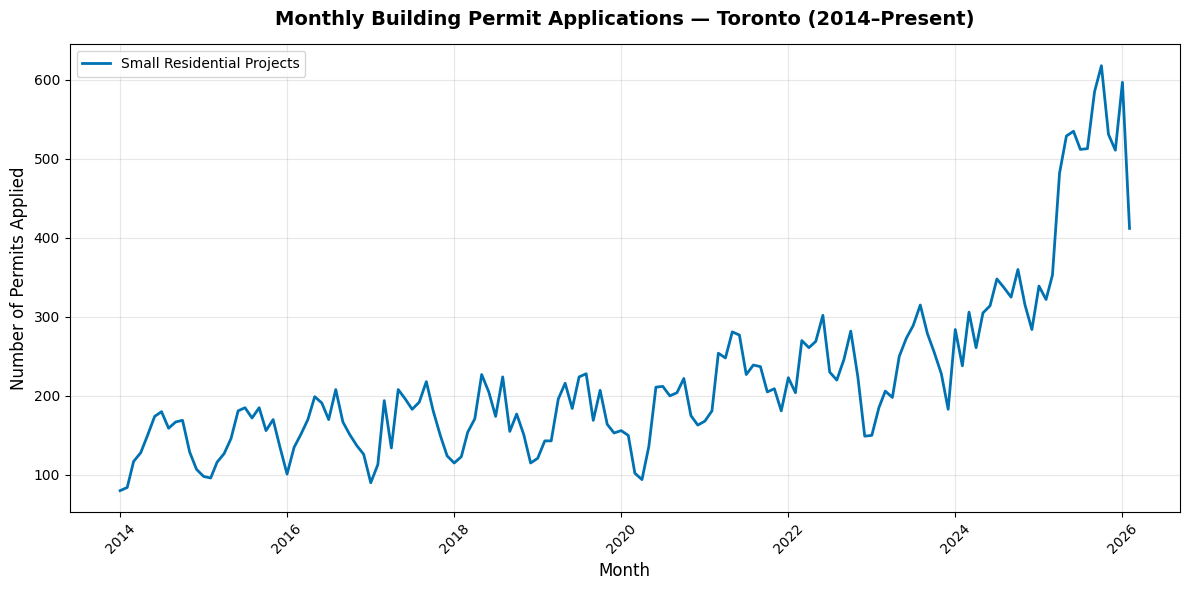

In [28]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(monthly.index, monthly, color="#0072B2", linewidth=2, label=top_type)

ax.set_title(
    "Monthly Building Permit Applications — Toronto (2014–Present)",
    fontsize=14, fontweight="bold", pad=14
)
ax.set_xlabel("Month", fontsize=12)
ax.set_ylabel("Number of Permits Applied", fontsize=12)

ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

> What software did you use to create your data visualization?
Jupyter notebook in VS code using python with pandas, matplotlib, and requests libraries.

> Who is your intended audience? Visual
City residents who want to understand how construction activity in Toronto has changed over time.
    
> What information or message are you trying to convey with your visualization?
The volume of permit applications in Toronto's small residential projects permit category to understand how economic events and seasonal patterns affect construction and development activity for small renovations.
    
> What aspects of design did you consider when making your visualization? How did you apply them? With what elements of your plots?
A line chart was chosen because it is the clearest way to show change over time. A solid blue line keeps the chart clean and accessible. Clear label and chart titles provides context. Light gridlines help visualize the dimension without cluttering the visual.
    
> How did you ensure that your data visualizations are reproducible? If the tool you used to make your data visualization is not reproducible, how will this impact your data visualization?
The notebook fetches data live from the Toronto Open Data API every time it runs. No manual downloads or local files are needed.
    
> How did you ensure that your data visualization is accessible? +
The color blue is a recommended color for a accessibility-safe palette. Font sizes are legible at a standard zoom. 
    
> Who are the individuals and communities who might be impacted by your visualization? 
Residents that want to understand permit activity in residential buildings. City inspectors that want to understand seasonal patters in application volumes. 
    
> How did you choose which features of your chosen dataset to include or exclude from your visualization?
I chose application date and permit type only to keep the story simple. Fields like builder name, description of work, or estimated construction cost were excluded becasue they add details per permit that are difficult to grasp at a high level visual. 
    
> What ‘underwater labour’ contributed to your final data visualization product?
Reviewing the CKAN API docs to find the correct csv endpoint, handling missing or malformed dates, filtering the data to get the permit I wanted to focus on in the desired timeframe.